# Marigold horizontal leafs detector by using the sacred framework 

## 1. Imports and configuration

In [63]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "science_jubilee").is_dir():
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not locate the science_jubilee repository root")

SRC_ROOT = REPO_ROOT / "src"
for path in (SRC_ROOT, REPO_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.filter_scene import run_filter_scene
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.target_horizontals import run_estimate_horizontal_targets
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.reconstruction import run_reconstruction
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.depth_scaling import run_scale_depth
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.extract_leafs import run_extract_leaf_clusters, run_leaf_clusters_to_opencv

import imageio
import open3d as o3d

DETECTOR_ROOT = SRC_ROOT / "science_jubilee/Vision/Marigold_Horizontal_leafs"
IMAGE_DIR = DETECTOR_ROOT / "input"
OUTPUT_DIR = DETECTOR_ROOT / "output/latest"
CONFIG_PATH = DETECTOR_ROOT / "config.yaml"
IMAGE_PATH = IMAGE_DIR / "latest.jpg"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)
segmentation_config = config.get("segmentation", {})

STEPS = 10
RUN_RECONSTRUCTION = False
TARGET_AUTO = False

def show(image, title=""):
    image_array = np.asarray(image)
    display_image = image_array if image_array.ndim == 3 else image_array
    plt.figure(figsize=(10, 7))
    plt.imshow(display_image, cmap="gray" if image_array.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

hardware = True

## 2. Capture the latest image (optional hardware step)

In [117]:
import time

if hardware:
    env = ".env.hardware"
else:
    env = ".env.mock"
    
session = MachineSession.from_env(env)
cam = session.camera
    
# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
if hardware == False:
    cam._image =  imageio.imread("input/test.png")
else:
    
    cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

image = cam.get_image()
image_out=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
cv2.imwrite(str(IMAGE_PATH), image_out)
print(f"Saved {IMAGE_PATH}")

Saved c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\input\latest.jpg


## 3. Load and inspect the image

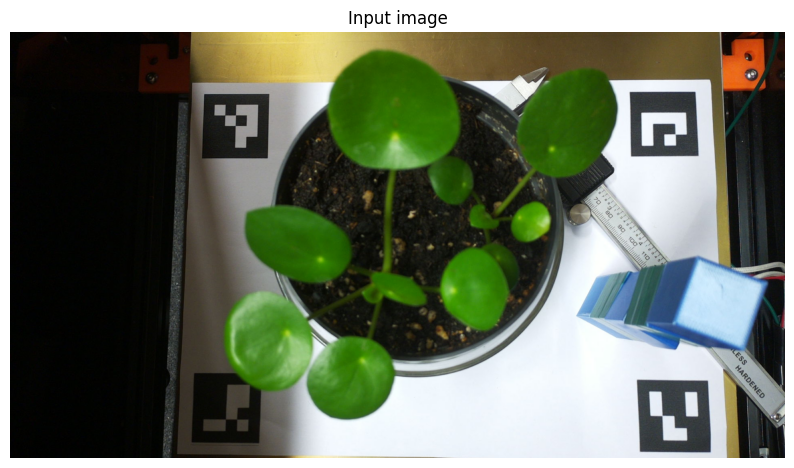

In [118]:
image2 = cv2.imread(str(IMAGE_PATH))

if image is None:
    raise FileNotFoundError(f"Unable to read {IMAGE_PATH}")
show(image, "Input image")


## 4. Segment the tray and plant

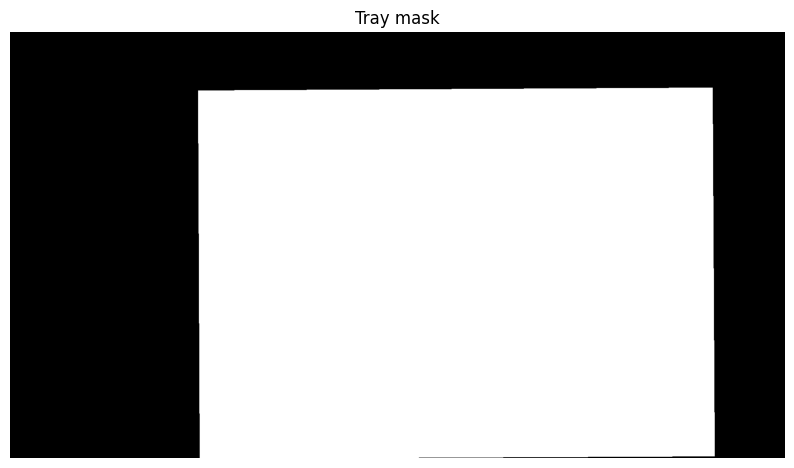

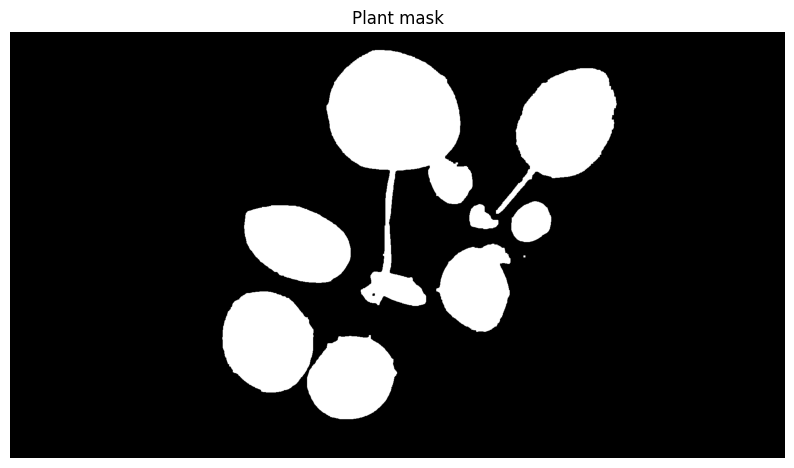

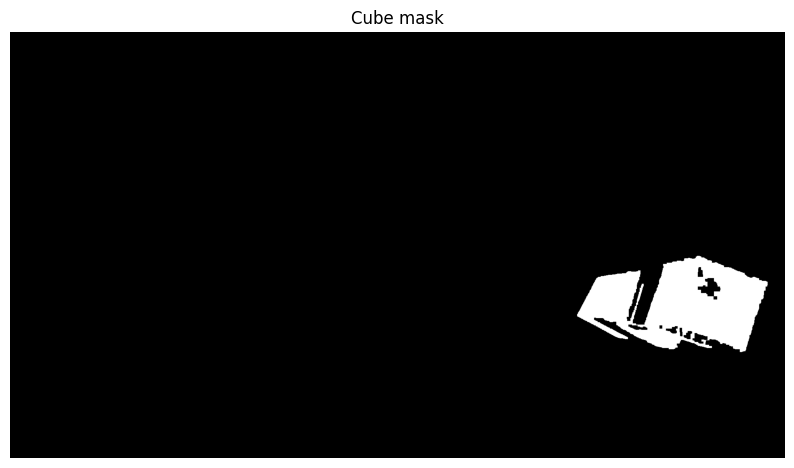

In [120]:
filtered = run_filter_scene(
    image=image,
    plant_hsv_lower=[70, 20, 25],
    plant_hsv_upper=[150, 100, 100],
    cube_hsv_lower=[170, 20, 39],
    cube_hsv_upper=[220, 100, 100]
)
show(filtered["tray_mask"], "Tray mask")
show(filtered["plant_mask"], "Plant mask")
show(filtered["cube_mask"], "Cube mask")

## 5. Estimate depth and surface normals

## With Marigold

[+] Using device: cuda
[+] Loading Marigold depth and normal models...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Running normal estimation...


Marigold predictions...:   0%|          | 0/1 [00:00<?, ?it/s]

Diffusion steps...:   0%|          | 0/1000 [00:00<?, ?it/s]

[+] Depth saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_depth.npy
[+] Normals saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_normals.npy
Depth shape: (1056, 1920)
Normals shape: (1056, 1920, 3)


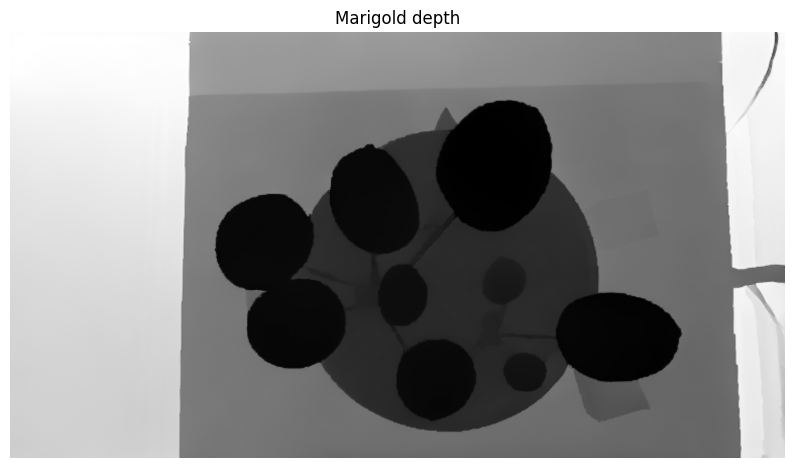

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


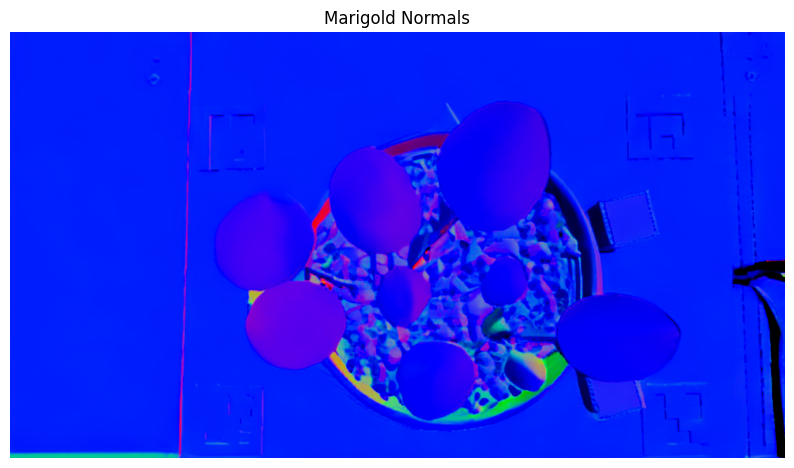

Range des profondeurs : min = 0.000, max = 1.000
Range des normales    : min = -1.000, max = 1.000


In [5]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_marigold import run_infer_depths_and_normals

inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    steps=1000,
    image_name=IMAGE_PATH.name,
)
depth_map = inference["depth"].squeeze()
normals = inference["normals"]

print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "Marigold depth")
show(normals,"Marigold Normals" )


# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

In [6]:

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

Range des profondeurs : min = 0.000, max = 0.998
Range des normales    : min = -1.000, max = 1.000


## With MoGe v3



Depth shape: (1056, 1920)
Normals shape: (1056, 1920, 3)


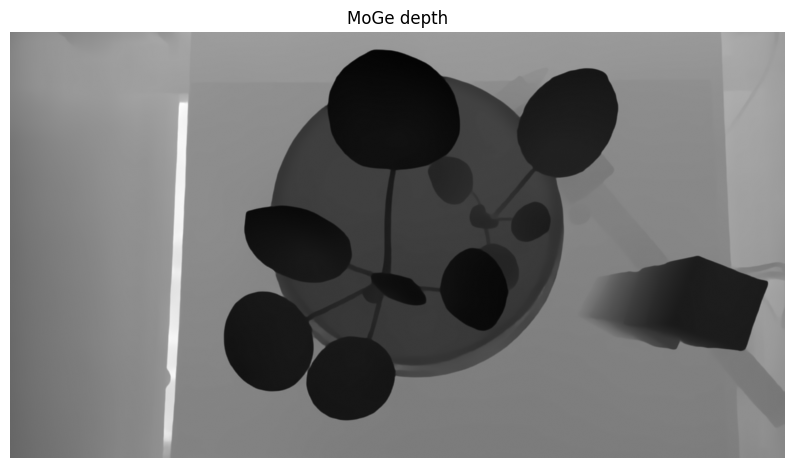

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9844812].


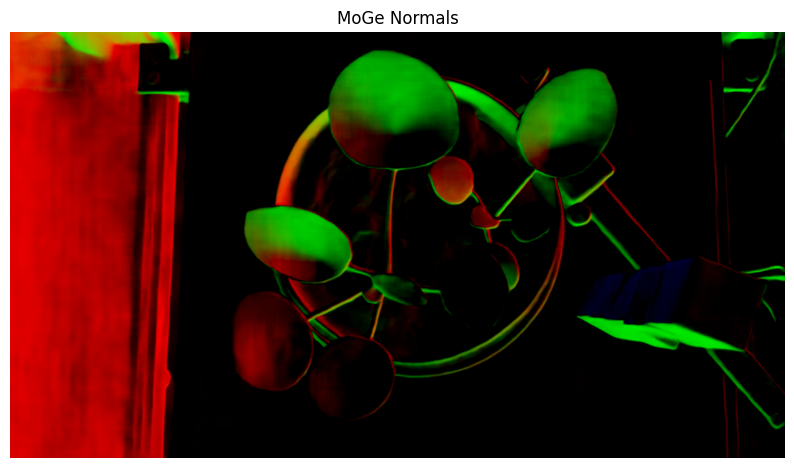

Range des profondeurs : min = 0.306, max = 1.072
Range des normales    : min = -1.000, max = 0.984


In [121]:
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_MoGe import run_infer_depths_and_normals
inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
    resolution_level=10
)
depth_map = inference["depth"]
normals = inference["normals"]
print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "MoGe depth")
show(normals,"MoGe Normals" )

# Print du range de la profondeur
print(f"Range des profondeurs : min = {np.min(depth_map):.3f}, max = {np.max(depth_map):.3f}")

# Print du range des normales
print(f"Range des normales    : min = {np.min(normals):.3f}, max = {np.max(normals):.3f}")

## 6. Detect horizontal leaf targets

## 6.1 Scale depth with tray and cube references


[DEPTH] Tray pixels: 880085, min=0.3438, max=0.7542
[DEPTH] Cube pixels: 63371, min=0.3782, max=0.6616
[DEPTH] Scaled range: min=171.12 mm, max=425.54 mm
[STEP 6.1] Depth scaling complete
  tray depth pixels: 880085
  tray depth range: 0.3437753915786743 -> 0.7541563510894775
  cube depth pixels: 63371
  depth_mm range: 171.12 -> 425.54 mm


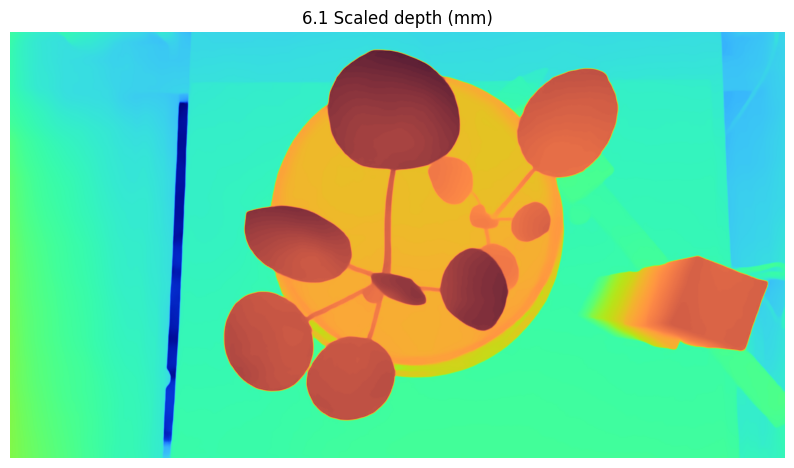

In [122]:
tray_mask = np.asarray(filtered["tray_mask"])
plant_mask = np.asarray(filtered["plant_mask"])
cube_mask = np.asarray(filtered["cube_mask"])

# The tray reference excludes plant pixels, as in the original pipeline.
tray_reference_mask = cv2.bitwise_and(
    tray_mask.astype(np.uint8),
    cv2.bitwise_not(plant_mask.astype(np.uint8)),
)

depth_scaling_result = run_scale_depth(
    image=image,
    depth_map=depth_map,
    tray_mask=tray_reference_mask,
    cube_mask=cube_mask,
    tray_z_mm=Z_DEPART,
    plant_height=None,
    scale_cube=125,
)

depth_mm = depth_scaling_result["depth_mm"]
tray_depth = depth_scaling_result["tray_depth"]
cube_depth = depth_scaling_result["cube_depth"]

print("[STEP 6.1] Depth scaling complete")
print(f"  tray depth pixels: {len(tray_depth)}")
print(f"  tray depth range: {depth_scaling_result['tray_depth_min']} -> {depth_scaling_result['tray_depth_max']}")
print(f"  cube depth pixels: {len(cube_depth)}")
print(f"  depth_mm range: {depth_mm.min():.2f} -> {depth_mm.max():.2f} mm")
show(depth_scaling_result["depth_preview"], "6.1 Scaled depth (mm)")

## 6.2 Create and inspect the reconstruction point cloud


In [123]:

reconstruction_result = run_reconstruction(
    image=image,
    depth_mm=depth_mm,
    camera=cam,
    meshing=False,
    alpha=0.005,
    decimate_ratio=0.5,
    output_dir=str(OUTPUT_DIR),
    image_name="pipeline_point_cloud.jpg",
)
point_cloud = reconstruction_result["point_cloud"]
print(f"[STEP 6.2] Reconstruction point cloud: {len(point_cloud.points)} points")
print(f"  bounds min: {np.round(point_cloud.get_min_bound(), 4)} m")
print(f"  bounds max: {np.round(point_cloud.get_max_bound(), 4)} m")
o3d.visualization.draw_geometries(
    [point_cloud],
    window_name="6.2 Reconstruction point cloud",
    width=1280,
    height=800,
)

[3D] Génération du nuage de points en mémoire...
[3D] Nuage brut généré avec 2027520 points.
[3D] Filtrage statistique des valeurs aberrantes...
[+] Nuage de points sauvegardé : c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\pipeline_point_cloud_point_cloud.ply
[STEP 6.2] Reconstruction point cloud: 1977098 points
  bounds min: [-0.2015 -0.1228 -0.4248] m
  bounds max: [ 0.2224  0.125  -0.1719] m


Processing leaf 1: 898 plant pixels
Processing leaf 2: 34824 plant pixels
Processing leaf 3: 0 plant pixels
Skipping leaf 3: no pixels belong to the plant
Processing leaf 4: 0 plant pixels
Skipping leaf 4: no pixels belong to the plant
Processing leaf 5: 1 plant pixels
Processing leaf 6: 0 plant pixels
Skipping leaf 6: no pixels belong to the plant
Processing leaf 7: 48918 plant pixels
Processing leaf 8: 75457 plant pixels
Processing leaf 9: 0 plant pixels
Skipping leaf 9: no pixels belong to the plant
Processing leaf 10: 42321 plant pixels
Processing leaf 11: 8914 plant pixels
Processing leaf 12: 0 plant pixels
Skipping leaf 12: no pixels belong to the plant
Processing leaf 13: 10 plant pixels
Processing leaf 14: 6452 plant pixels
Processing leaf 15: 0 plant pixels
Skipping leaf 15: no pixels belong to the plant
Processing leaf 16: 358 plant pixels
Processing leaf 17: 205 plant pixels
Processing leaf 18: 9770 plant pixels
Processing leaf 19: 0 plant pixels
Skipping leaf 19: no pixels 

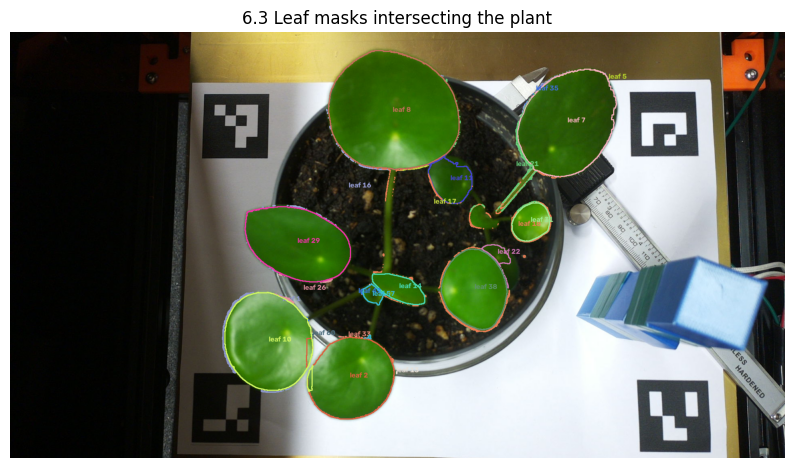

In [126]:
## 6.3 Extract leaf clusters and create the OpenCV mask overlay
leaf_clusters = run_extract_leaf_clusters(
    point_cloud,
    distance_threshold=0.00113,
    min_points=20,
    size_threshold=1e-5,
    shape_threshold=0.98,
    height_ratio=0.01,
    voxel_size=0.0005,
)

# Build the camera-coordinate map used to project 3D leaf clusters to image pixels.
h, w = depth_mm.shape
u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
pixels = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32)
undistorted = cv2.undistortPoints(
    pixels.reshape(-1, 1, 2),
    np.asarray(cam.K, dtype=np.float32),
    np.asarray(cam.dist, dtype=np.float32),
)
x_norm = undistorted[:, 0, 0].reshape(h, w)
y_norm = undistorted[:, 0, 1].reshape(h, w)
z_m = depth_mm / 1000.0
xyz_map = np.dstack((x_norm * z_m, -y_norm * z_m, -z_m))

leaf_mask_result = run_leaf_clusters_to_opencv(
    leaf_clusters=leaf_clusters,
    xyz_map=xyz_map,
    image_shape=image.shape,
)
leaf_labels_img = leaf_mask_result["labels_img"]
leaf_masks = leaf_mask_result["masks"]
leaf_contours = leaf_mask_result["contours"]

leaf_overlay = image.copy()
if leaf_overlay.ndim == 2:
    leaf_overlay = cv2.cvtColor(leaf_overlay, cv2.COLOR_GRAY2RGB)

plant_binary_mask = (plant_mask > 0).astype(np.uint8)
visible_leaf_count = 0
visible_leaf_masks = []
for leaf_id, (contour, leaf_mask) in enumerate(zip(leaf_contours, leaf_masks), start=1):
    plant_pixels = cv2.bitwise_and(leaf_mask, plant_binary_mask * 255)
    plant_pixel_count = int(np.count_nonzero(plant_pixels))
    print(f"Processing leaf {leaf_id}: {plant_pixel_count} plant pixels")
    if plant_pixel_count == 0:
        print(f"Skipping leaf {leaf_id}: no pixels belong to the plant")
        continue

    visible_leaf_count += 1
    visible_leaf_masks.append(plant_pixels)
    color = tuple(
        int(value)
        for value in np.random.default_rng(leaf_id).integers(40, 255, 3)
    )
    plant_contours, _ = cv2.findContours(
        plant_pixels,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    cv2.drawContours(leaf_overlay, plant_contours, -1, color, 2)
    moments = cv2.moments(plant_pixels)
    if moments["m00"]:
        center = (
            int(moments["m10"] / moments["m00"]),
            int(moments["m01"] / moments["m00"]),
        )
        cv2.putText(
            leaf_overlay,
            f"leaf {leaf_id}",
            center,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2,
        )

leaf_masks = visible_leaf_masks
print(f"[STEP 6.3] Leaf clusters found: {len(leaf_clusters)}")
print(f"  Leaf masks with plant pixels: {visible_leaf_count}")
show(leaf_overlay, "6.3 Leaf masks intersecting the plant")

[STEP 6.4] Targets detected: 9
  Five highest targets displayed and printed:
  Selected normal std values: [0.026844318956136703, 0.023112118244171143, 0.024874670431017876, 0.024939540773630142, 0.024615537375211716, 0.027462121099233627, 0.01557956449687481, 0.010353077203035355, 0.023461807519197464]
  1. T8: weighted centroid=[1154, 550] | XYZ=[  24.12   -0.69 -184.3 ] mm
  2. T3: weighted centroid=[881, 261] | XYZ=[ -10.3    35.81 -187.09] mm
  3. T7: weighted centroid=[625, 556] | XYZ=[ -43.66   -1.5  -190.52] mm
  4. T4: weighted centroid=[642, 737] | XYZ=[ -42.29  -25.29 -194.32] mm
  5. T1: weighted centroid=[842, 847] | XYZ=[ -15.9   -39.84 -194.62] mm


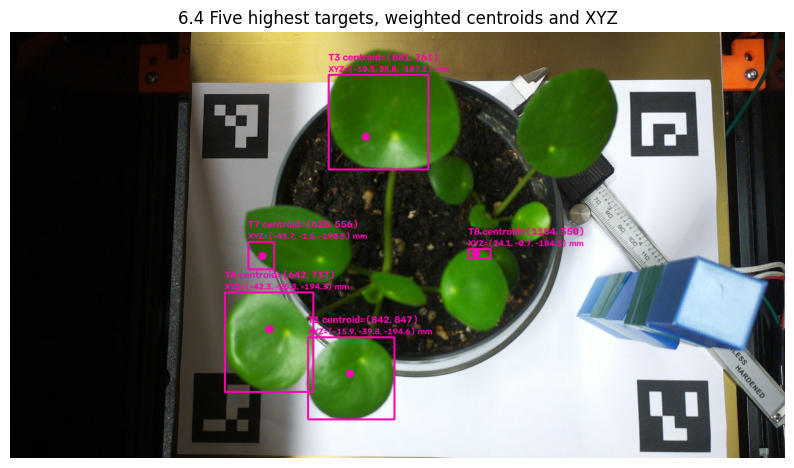

In [127]:
## 6.4 Target one horizontal zone per leaf
targets_result = run_estimate_horizontal_targets(
    image=image,
    depth_mm=depth_mm,
    point_cloud=point_cloud,
    labels_img=leaf_labels_img,
    plant_mask=plant_mask,
    normals=normals,
    min_area_px=500,
    max_area_px=150000,
    cluster_eps_mm=2.0,
    cluster_eps_normal=0.03,
    normal_threshold=0.90,
    camera=cam,
)

targets = targets_result["targets"]
target_labels_img = targets_result["labels_img"]
target_normal_stds = targets_result["normal_stds"]
highest_targets = sorted(
    targets,
    key=lambda item: item["xyz_mm"][2],
    reverse=True,
)[:5]

# Draw only the five highest targets on the image.
target_overlay = image.copy()
pink = (255, 0, 180)
font = cv2.FONT_HERSHEY_SIMPLEX
for target in highest_targets:
    u, v = target["pixel"]
    x_mm, y_mm, z_mm = target["xyz_mm"]
    left, top, width, height = target["bbox"]
    cv2.circle(target_overlay, (u, v), 10, pink, -1)
    cv2.rectangle(
        target_overlay,
        (left, top),
        (left + width, top + height),
        pink,
        3,
    )
    text_x = max(10, left)
    text_y = max(30, top - 35)
    cv2.putText(
        target_overlay,
        f"T{target['id']} centroid=({u}, {v})",
        (text_x, text_y),
        font,
        0.8,
        pink,
        2,
        cv2.LINE_AA,
    )
    cv2.putText(
        target_overlay,
        f"XYZ=({x_mm:.1f}, {y_mm:.1f}, {z_mm:.1f}) mm",
        (text_x, text_y + 28),
        font,
        0.7,
        pink,
        2,
        cv2.LINE_AA,
    )

print(f"[STEP 6.4] Targets detected: {len(targets)}")
print("  Five highest targets displayed and printed:")
print(f"  Selected normal std values: {target_normal_stds}")
for index, target in enumerate(highest_targets, start=1):
    print(
        f"  {index}. T{target['id']}: weighted centroid={target['pixel']} | "
        f"XYZ={np.round(target['xyz_mm'], 2)} mm"
    )
show(target_overlay, "6.4 Five highest targets, weighted centroids and XYZ")

## 7. Select a target

In [128]:
if not targets:
    raise RuntimeError("No horizontal targets detected; inspect the masks or rerun inference.")

highest_targets = sorted(
    targets,
    key=lambda item: item["xyz_mm"][2],
    reverse=True,
)[:5]

if TARGET_AUTO:
    target = highest_targets[0]
else:
    for index, candidate in enumerate(highest_targets, start=1):
        print(index, candidate)
    print("Select a target among the five highest targets")

1 {'id': 8, 'leaf_id': 38, 'pixel': [1154, 550], 'area_px': 672, 'bbox': [1135, 539, 55, 23], 'normal_confidence': -0.9353123307228088, 'normal_std': 0.010353077203035355, 'xyz_mm': [24.119163513183594, -0.6871760487556458, -184.3009490966797], 'normal': [-0.3231084942817688, -0.14419318735599518, -0.9353123307228088]}
2 {'id': 3, 'leaf_id': 8, 'pixel': [881, 261], 'area_px': 22165, 'bbox': [789, 108, 247, 234], 'normal_confidence': -0.9788771271705627, 'normal_std': 0.024874670431017876, 'xyz_mm': [-10.297677040100098, 35.80744934082031, -187.0919952392578], 'normal': [0.20208831131458282, -0.030984481796622276, -0.9788771271705627]}
3 {'id': 7, 'leaf_id': 29, 'pixel': [625, 556], 'area_px': 1102, 'bbox': [590, 521, 64, 68], 'normal_confidence': -0.9170469045639038, 'normal_std': 0.01557956449687481, 'xyz_mm': [-43.662353515625, -1.49770188331604, -190.51889038085938], 'normal': [0.3705747425556183, 0.1473073810338974, -0.9170469045639038]}
4 {'id': 4, 'leaf_id': 10, 'pixel': [642, 73

In [43]:
selected_index = 3
if not 1 <= selected_index <= len(highest_targets):
    raise IndexError(
        f"selected_index must be between 1 and {len(highest_targets)}"
    )
target = highest_targets[selected_index - 1]
print("Selected target:", target)
print(target["xyz_mm"])

Selected target: {'id': 4, 'leaf_id': 12, 'pixel': [1512, 292], 'area_px': 21316, 'bbox': [1398, 198, 197, 222], 'normal_confidence': -0.9489968419075012, 'normal_std': 0.024368174374103546, 'xyz_mm': [61.7657585144043, 28.073657989501953, -165.85867309570312], 'normal': [-0.24309229850769043, -0.20077620446681976, -0.9489968419075012]}
[61.7657585144043, 28.073657989501953, -165.85867309570312]


## 8. Move into the target

In [97]:
supplementary_offset_xyz = [
        -3,
        21.0,
        0,
    ]
# On se déplace vers le target en gardant la même hauteur
if hardware:    
    nav= session.free_navigator
    nav.move_to(
            z=Z_DEPART + cam.offset[2] + target["xyz_mm"][2] +supplementary_offset_xyz[2] +30 , speed=1000.0, wait=True
        )
    nav.move_to(
        x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
        y=Y_DEPART + target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
        speed=3000.0,
        wait=True,
    )
    nav.move_to(
        z=Z_DEPART + cam.offset[2] + target["xyz_mm"][2] +supplementary_offset_xyz[2], speed=1000.0, wait=True
    )

In [129]:
for target in highest_targets:
    supplementary_offset_xyz = [
        -3,
        21.0,
       +10,
    ]
    # On se déplace vers le target en gardant la même hauteur
    if hardware:    
        nav= session.free_navigator
        nav.move_to(
                z=Z_DEPART + cam.offset[2] + target["xyz_mm"][2] +supplementary_offset_xyz[2] +30 , speed=1000.0, wait=True
            )
        nav.move_to(
            x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
            y=Y_DEPART + target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
            speed=3000.0,
            wait=True,
        )
        nav.move_to(
            z=Z_DEPART + cam.offset[2] + target["xyz_mm"][2] +supplementary_offset_xyz[2], speed=1000.0, wait=True
        )

## 9. Create mesh 

In [99]:
import open3d as o3d
results = run_reconstruction(
    image=image,
    depth_mm=depth_mm,
    camera=cam,
    meshing=True,
    alpha=0.005,           # Paramètre de l'Alpha Shape (plus petit = plus fin/troué)
    decimate_ratio=0.5,    # Réduit le nombre de triangles de 50%
    output_dir="./output_3d",
    image_name="test_plant.jpg"
)

# 4. Extraction du maillage
mesh = results["mesh"]

# 5. Visualisation interactive avec Open3D
print("[Visualisation] Ouverture de la fenêtre Open3D... (Fermez la fenêtre pour rendre la main au script)")

# On recalcule les normales pour que la lumière s'affiche correctement sur le mesh
mesh.compute_vertex_normals()

o3d.visualization.draw_geometries(
    [mesh],
    window_name="Reconstruction 3D - Maillage des feuilles",
    width=1280,
    height=720,
    mesh_show_wireframe=False,   
    mesh_show_back_face=True     
)

[3D] Génération du nuage de points en mémoire...
[3D] Nuage brut généré avec 2027520 points.
[3D] Filtrage statistique des valeurs aberrantes...
[+] Nuage de points sauvegardé : output_3d\test_plant_point_cloud.ply
Triangles generated : 602 494
 Quadratic decimation  keeping only 301 247 faces.
[+] Maillage sauvegardé : output_3d\test_plant_mesh.ply
[Visualisation] Ouverture de la fenêtre Open3D... (Fermez la fenêtre pour rendre la main au script)


## DEBUG ONLY: find best parameters for segentation and clustering of plants 

In [50]:
import cv2
import numpy as np
from skimage.segmentation import watershed
from skimage.filters import sobel
from sklearn.cluster import DBSCAN

tray_mask=filtered["tray_mask"]
plant_mask=filtered["plant_mask"]
cube_mask=filtered["cube_mask"]
config = {
    "camera": {
        "cx": 966.6098775996533,
        "cy": 533.9822650713481,
        "dist": [
            -0.01774652120816888,
            0.34775989653378375,
            -8.43022105306137e-05,
            0.0013051523863665852,
            -0.7666010432176091,
        ],
        "fx": 1453.20885729982,
        "fy": 1462.5327058475916,
    },
    "physical": {
        "tray_z_mm": 320.00,
        "plant_height_mm": 155.0,
        "tray_reference_mm": 320.00,
    },
    "filtering": {"min_area_px": 2500,
                  "max_area_px": 150000,
  "min_normal_z": 0.90,
  "cluster_eps_mm": 2,
  "cluster_eps_normal": 0.03
        }
}
intrinsics=config["camera"]
plant_height=None
scale_cube=None

In [8]:

def depth_to_camera_xyz(
    depth_map: np.ndarray, u: float, v: float, intrinsics: dict
) -> np.ndarray:
    # Thanks to the depth estimated  we can compute the real world cordinates using camera pinhole model with iis calibrated camera parameters
    h, w = depth_map.shape[:2]
    u0 = int(np.clip(round(u), 0, w - 1))
    v0 = int(np.clip(round(v), 0, h - 1))
    z_value = np.asarray(depth_map[v0, u0]).reshape(-1)[0]
    z = float(z_value)

    K = np.array(
        [
            [intrinsics["fx"], 0, intrinsics["cx"]],
            [0, intrinsics["fy"], intrinsics["cy"]],
            [0, 0, 1],
        ],
        dtype=np.float32,
    )
    # Improvement of the model by including the distortion parameters given py the opencv calibration

    dist_np = np.array(intrinsics["dist"], dtype=np.float32)
    point_2d = np.array([[[u, v]]], dtype=np.float32)

    undistorted_pt = cv2.undistortPoints(point_2d, K, dist_np)
    x_norm = undistorted_pt[0, 0, 0]
    y_norm = undistorted_pt[0, 0, 1]

    x = x_norm * z
    y = y_norm * z
    return np.array([x, y, z], dtype=np.float32)



[DEBUG] START TARGET ESTIMATION PIPELINE
[1. Depth Scaling] Min: 125.19 mm | Max: 502.99 mm


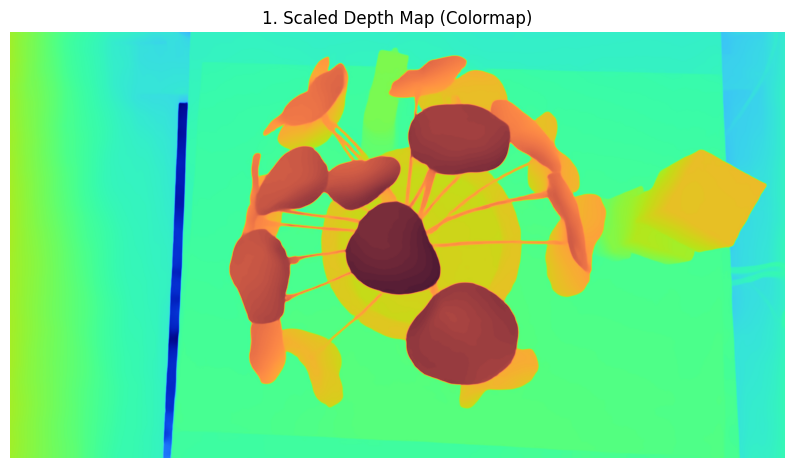

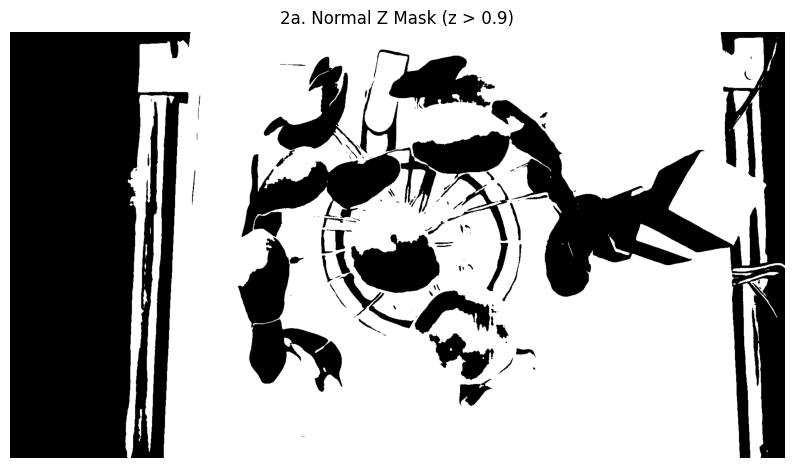

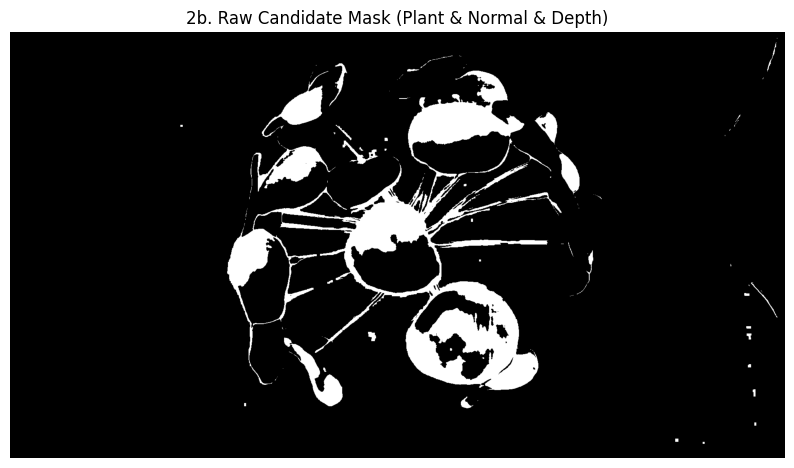

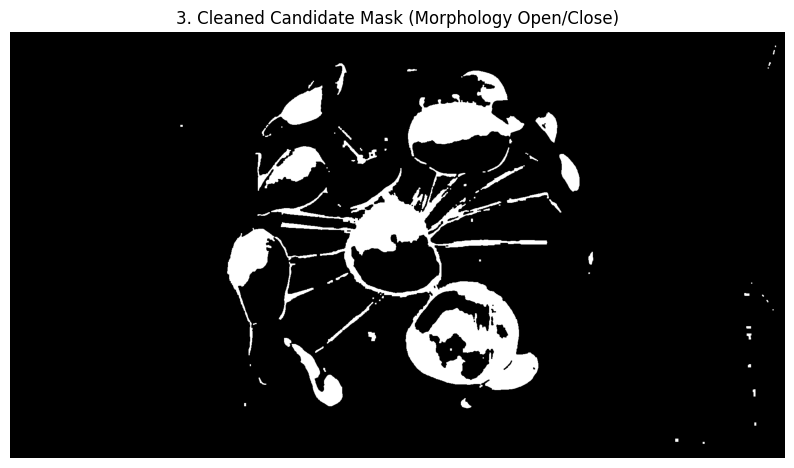

[4. Clustering] 1er DBSCAN (Spatial 3D) sur 154820 points (eps=2.0mm)...
    -> Blobs spatiaux initiaux  : 6
    -> Blobs scindés par normal : 0
    -> Blobs cibles finaux      : 6



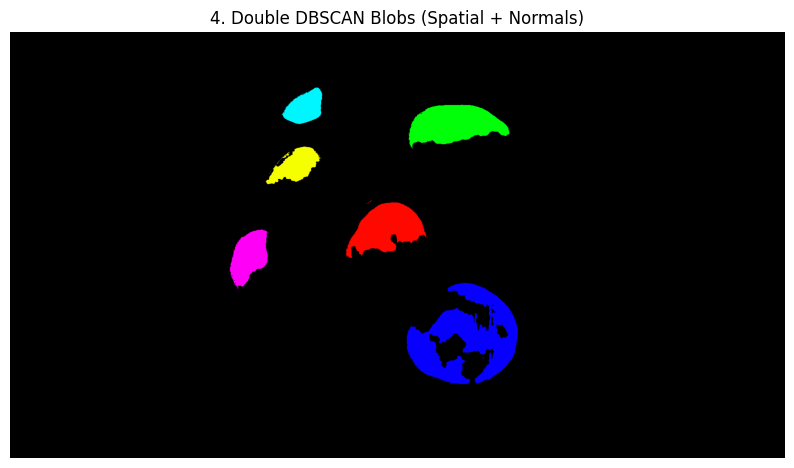

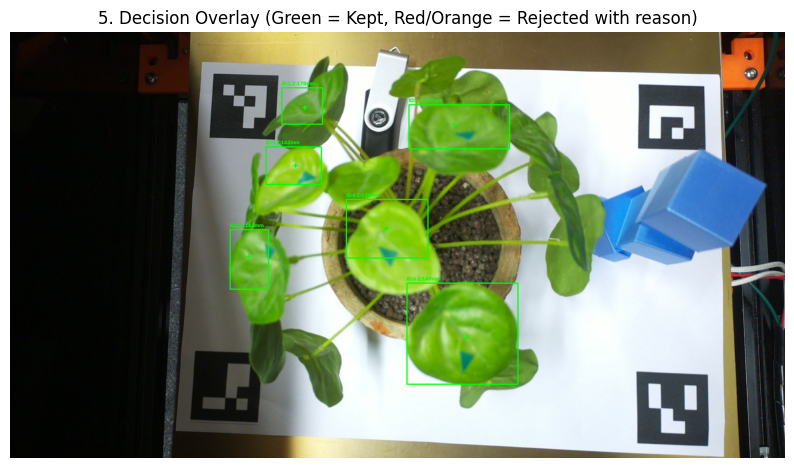


------------------------------ SUMMARY ------------------------------
Total initial blobs: 6
  - Dropped by 'area': 0
  - Dropped by 'extent': 0
  - Dropped by 'border': 0
  - Dropped by 'normal_vector': 0
  - Dropped by 'normal_conf': 0
  - Dropped by 'depth_std': 0
Final valid targets detected: 6



[{'id': 1,
  'pixel': [730, 189],
  'area_px': 5817,
  'bbox': [673, 140, 101, 90],
  'normal_confidence': array([[   -0.12205,    -0.13289,    -0.14608, ...,   -0.039446,   -0.036738,    -0.03194],
         [   -0.13041,    -0.13968,    -0.15084, ...,   -0.040491,   -0.038088,   -0.033499],
         [   -0.14101,    -0.14851,     -0.1574, ...,   -0.041166,   -0.039108,   -0.034795],
         ...,
         [   -0.36187,    -0.35795,    -0.35385, ...,    -0.26488,    -0.26515,    -0.26458],
         [   -0.35797,    -0.35442,    -0.35035, ...,    -0.25634,    -0.25695,    -0.25674],
         [   -0.35506,    -0.35208,     -0.3481, ...,    -0.24966,    -0.25056,    -0.25052]], dtype=float32),
  'xyz_mm': [-28.997417449951172, -41.98043441772461, 177.9929656982422]},
 {'id': 2,
  'pixel': [1100, 231],
  'area_px': 17417,
  'bbox': [988, 182, 249, 109],
  'normal_confidence': array([[   -0.12205,    -0.13289,    -0.14608, ...,   -0.039446,   -0.036738,    -0.03194],
         [   -0.13041, 

In [53]:

def return_targets():
    print("\n" + "=" * 50)
    print("[DEBUG] START TARGET ESTIMATION PIPELINE")
    print("=" * 50)

# -------------------------------------------------------------
    # 1. Depth Map Scaling & Visualization
    # -------------------------------------------------------------
    tray_depth_values = depth_map[tray_mask > 0]
    if tray_depth_values.size == 0 or np.isclose(np.max(tray_depth_values), 0.0):
        print("[!] Warning: Tray mask is empty or max depth is 0!")
        max_tray_depth = 1.0
    else:
        max_tray_depth = np.max(tray_depth_values)

    tray_z_mm = config["physical"]["tray_z_mm"]
    depth_mm = depth_map * (tray_z_mm / max_tray_depth)
    if plant_height != None:
            depth_mm= (depth_map - np.min(depth_map) )*plant_height/(max_tray_depth-np.min(depth_map)) + (tray_z_mm-plant_height)
    if scale_cube!=None:
            cube_depth = depth_map[cube_mask > 0]
            if cube_depth.size == 0 or np.isclose(np.max(cube_depth), 0.0):
                print("[!] Warning: Cube mask is empty or max depth is 0!")
            else:
                print(
                    f"[+] Cube depth values: {cube_depth.size} pixels, "
                    f"min={np.min(cube_depth) if cube_depth.size > 0 else 0:.2f}, "
                    f"max={np.max(cube_depth):.2f}"
                )
                depth_mm= (depth_map - np.min(cube_depth) )*scale_cube/(max_tray_depth-np.min(cube_depth)) + (tray_z_mm-scale_cube)
    # Remplacement des infinis (et NaNs éventuels) par 400.0 mm
    depth_mm[np.isinf(depth_mm)] = 400.0
    depth_mm[np.isnan(depth_mm)] = 400.0

    print(
        f"[1. Depth Scaling] Min: {np.min(depth_mm):.2f} mm | Max: {np.max(depth_mm):.2f} mm"
    )

    # Visual 1: Scaled Depth Colormap
    depth_vis = cv2.normalize(
        depth_mm, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )
    depth_colormap = cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO)
    show(depth_colormap, "1. Scaled Depth Map (Colormap)")

    # -------------------------------------------------------------
    # 2. Mask Generation & Intermediate Visuals
    # -------------------------------------------------------------
    normal_z = normals[:, :, 2]
    normal_threshold = float(config.get("filtering", {}).get("min_normal_z", 0.94))

    normal_mask = (np.abs(normal_z)> normal_threshold).astype(np.uint8) * 255
    depth_valid_mask = (depth_mm > 0).astype(np.uint8) * 255

    candidate_mask_raw = cv2.bitwise_and(plant_mask, normal_mask)
    candidate_mask_raw = cv2.bitwise_and(candidate_mask_raw, depth_valid_mask)

    # Visual 2: Filtering intermediate masks
    show(normal_mask, f"2a. Normal Z Mask (z > {normal_threshold})")
    show(candidate_mask_raw, "2b. Raw Candidate Mask (Plant & Normal & Depth)")

    # -------------------------------------------------------------
    # 3. Morphology & Cleaning
    # -------------------------------------------------------------
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(candidate_mask_raw, cv2.MORPH_OPEN, kernel)
    candidate_mask = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    show(candidate_mask, "3. Cleaned Candidate Mask (Morphology Open/Close)")

    intrinsics = {
            "fx": float(config["camera"]["fx"]),
            "fy": float(config["camera"]["fy"]),
            "cx": float(config["camera"]["cx"]),
            "cy": float(config["camera"]["cy"]),
            "dist": config["camera"]["dist"],
        }

    # -------------------------------------------------------------
    # 4. Double Clustering DBSCAN (Distance 3D puis Différence Normale Z)
    # -------------------------------------------------------------
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px", 500))
    max_area_px = int(filtering_cfg.get("max_area_px", 12000))
    
    # Paramètres de clustering (ajustables dans config.yaml)
    cluster_eps_mm = float(filtering_cfg.get("cluster_eps_mm", 2.0))       # Tolérance distance 3D (mm)
    cluster_eps_normal = float(filtering_cfg.get("cluster_eps_normal", 0.5)) # Tolérance diff normal_z (ex: 0.05)

    # --- Étape A : Vectorisation du calcul XYZ (Pin-hole model) ---
    h, w = depth_mm.shape
    u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
    
    points_2d = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32).reshape(-1, 1, 2)
    
    K = np.array([
        [intrinsics["fx"], 0, intrinsics["cx"]],
        [0, intrinsics["fy"], intrinsics["cy"]],
        [0, 0, 1]
    ], dtype=np.float32)
    dist_np = np.array(intrinsics["dist"], dtype=np.float32)

    undistorted_pts = cv2.undistortPoints(points_2d, K, dist_np)
    x_norm = undistorted_pts[:, 0, 0].reshape(h, w)
    y_norm = undistorted_pts[:, 0, 1].reshape(h, w)

    X = x_norm * depth_mm
    Y = y_norm * depth_mm
    XYZ_map = np.dstack((X, Y, depth_mm))

    # --- Étape B : Extraction des points candidats ---
    valid_mask = candidate_mask > 0
    valid_XYZ = XYZ_map[valid_mask]
    valid_normals_z = normal_z[valid_mask].reshape(-1, 1) # Format 2D requis pour DBSCAN
    valid_coords = np.column_stack(np.where(valid_mask))  # Format (y, x)

    print(f"[4. Clustering] 1er DBSCAN (Spatial 3D) sur {len(valid_XYZ)} points (eps={cluster_eps_mm}mm)...")
    
    # --- Étape C : Premier DBSCAN (Distance spatiale 3D) ---
    dbscan_spatial = DBSCAN(eps=cluster_eps_mm, min_samples=min_area_px // 4, n_jobs=-1)
    labels_spatial = dbscan_spatial.fit_predict(valid_XYZ)

    # Variables pour stocker les clusters finaux isolés
    final_labels_img = np.zeros((h, w), dtype=np.int32)
    current_label_id = 1
    split_by_normal_count = 0

    unique_spatial_labels = np.unique(labels_spatial)

    # --- Étape D : Deuxième DBSCAN (Orientation normal_z) sur chaque sous-groupe ---
    for sp_lbl in unique_spatial_labels:
        if sp_lbl == -1: 
            continue # Ignorer le bruit
            
        # Index des points appartenant à ce cluster spatial
        idx_cluster = np.where(labels_spatial == sp_lbl)[0]
        
        # S'il y a très peu de points, inutile de relancer un DBSCAN
        if len(idx_cluster) < min_area_px:
            continue
            
        # Récupération des valeurs normal_z du cluster
        cluster_normals = valid_normals_z[idx_cluster]
        
        # Second DBSCAN basé uniquement sur la similarité de l'orientation (normal_z)
        dbscan_norm = DBSCAN(eps=cluster_eps_normal, min_samples=min_area_px // 8, n_jobs=-1)
        labels_norm = dbscan_norm.fit_predict(cluster_normals)
        
        unique_norm_labels = np.unique(labels_norm)
        if len(unique_norm_labels) > 2: # Plus d'un groupe valide détecté (hors bruit -1)
            split_by_normal_count += 1
            
        # --- Étape E : Filtrage final et assignation sur l'image 2D ---
        for n_lbl in unique_norm_labels:
            if n_lbl == -1:
                continue
                
            idx_sub_cluster = idx_cluster[labels_norm == n_lbl]
            area = len(idx_sub_cluster)
            
            if min_area_px <= area <= max_area_px:
                y_c = valid_coords[idx_sub_cluster, 0]
                x_c = valid_coords[idx_sub_cluster, 1]
                final_labels_img[y_c, x_c] = current_label_id
                current_label_id += 1

    # --- Étape F : Construction des stats OpenCV manuellement ---
    # Cette étape remplace cv2.connectedComponentsWithStats pour empêcher
    # la refusion de 2 feuilles qui se touchent en 2D mais ont été séparées par DBSCAN.
    num_labels = current_label_id
    labels = final_labels_img
    stats = np.zeros((num_labels, 5), dtype=np.int32)
    centroids = np.zeros((num_labels, 2), dtype=np.float64)

    for i in range(1, num_labels):
        y_idx, x_idx = np.where(labels == i)
        stats[i, cv2.CC_STAT_LEFT] = x_idx.min()
        stats[i, cv2.CC_STAT_TOP] = y_idx.min()
        stats[i, cv2.CC_STAT_WIDTH] = x_idx.max() - x_idx.min() + 1
        stats[i, cv2.CC_STAT_HEIGHT] = y_idx.max() - y_idx.min() + 1
        stats[i, cv2.CC_STAT_AREA] = len(x_idx)
        centroids[i, 0] = x_idx.mean()
        centroids[i, 1] = y_idx.mean()

    total_blobs = num_labels - 1
    
    print(f"    -> Blobs spatiaux initiaux  : {len(unique_spatial_labels) - 1}")
    print(f"    -> Blobs scindés par normal : {split_by_normal_count}")
    print(f"    -> Blobs cibles finaux      : {total_blobs}\n")

    # Visual 4: Colored DBSCAN Blobs
    if num_labels > 1:
        label_hue = np.uint8(179 * labels / np.max(labels))
        blank_ch = 255 * np.ones_like(label_hue)
        labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
        labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
        labeled_img[labels == 0] = 0
        show(labeled_img, "4. Double DBSCAN Blobs (Spatial + Normals)")
    # -------------------------------------------------------------
    # 5. Filtering Criteria & Debug Overlay
    # -------------------------------------------------------------
    intrinsics = {
        "fx": float(config["camera"]["fx"]),
        "fy": float(config["camera"]["fy"]),
        "cx": float(config["camera"]["cx"]),
        "cy": float(config["camera"]["cy"]),
        "dist": config["camera"]["dist"],
    }
    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px",500))

    targets = []
    rejection_stats = {
        "area": 0,
        "extent": 0,
        "border": 0,
        "normal_vector": 0,
        "normal_conf": 0,
        "depth_std": 0,
    }

    # Prepare visual overlay (RGB copy)
    debug_overlay = image.copy()
    if len(debug_overlay.shape) == 2 or debug_overlay.shape[2] == 1:
        debug_overlay = cv2.cvtColor(debug_overlay, cv2.COLOR_GRAY2BGR)

    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        left = int(stats[label_idx, cv2.CC_STAT_LEFT])
        top = int(stats[label_idx, cv2.CC_STAT_TOP])
        width = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        height = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        cx, cy = centroids[label_idx]
        u, v = int(round(cx)), int(round(cy))

        # Check 1: Area
        if area < min_area_px:
            print(f"blob with area {area} rejected because less than {min_area_px}")
            rejection_stats["area"] += 1
            cv2.rectangle(
                debug_overlay,
                (left, top),
                (left + width, top + height),
                (0, 0, 255),
                1,
            )
            cv2.putText(
                debug_overlay,
                f"#{label_idx}: Area",
                (left, max(15, top - 4)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4,
                (0, 0, 255),
                1,
            )
            continue
        xyz = depth_to_camera_xyz(depth_mm, u, v, intrinsics)
       

        # ACCEPTED TARGET -> Green bounding box and centroid marker
        cv2.rectangle(
            debug_overlay,
            (left, top),
            (left + width, top + height),
            (0, 255, 0),
            2,
        )
        cv2.drawMarker(
            debug_overlay,
            (u, v),
            (0, 255, 0),
            markerType=cv2.MARKER_CROSS,
            markerSize=10,
            thickness=2,
        )
        cv2.putText(
            debug_overlay,
            f"ID:{label_idx} Z:{xyz[2]:.0f}mm",
            (left, max(18, top - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (0, 255, 0),
            2,
        )

        targets.append(
            {
                "id": label_idx,
                "pixel": [int(u), int(v)],
                "area_px": area,
                "bbox": [left, top, width, height],
                "normal_confidence": normal_z,
                "xyz_mm": [float(xyz[0]), float(xyz[1]), float(xyz[2])],
            }
        )

    # Visual 5: Final diagnostic overlay
    show(
        debug_overlay,
        "5. Decision Overlay (Green = Kept, Red/Orange = Rejected with reason)",
    )

    print("\n" + "-" * 30 + " SUMMARY " + "-" * 30)
    print(f"Total initial blobs: {total_blobs}")
    for reason, count in rejection_stats.items():
        print(f"  - Dropped by '{reason}': {count}")
    print(f"Final valid targets detected: {len(targets)}")
    print("=" * 69 + "\n")

    return targets
return_targets()

Test avec le clustering de feuillles avant les dbscan


In [14]:
import cv2
import numpy as np
import open3d as o3d
from sklearn.cluster import DBSCAN

SHOW_LEAF_CLUSTERS_3D = True


def run_extract_leaf_clusters(
    pcd,
    distance_threshold,
    min_points,
    size_threshold,
    shape_threshold,
    height_ratio,
):
    downsampled = pcd.voxel_down_sample(voxel_size=0.005)
    labels = np.asarray(
        downsampled.cluster_dbscan(
            eps=distance_threshold,
            min_points=min_points,
            print_progress=False,
        )
    )
    if labels.size == 0:
        return []

    points = np.asarray(downsampled.points)
    z_min = points[:, 2].min()
    total_height = points[:, 2].max() - z_min
    clusters = []
    for label in range(labels.max() + 1):
        cluster_points = points[labels == label]
        if len(cluster_points) < 3:
            continue
        eigenvalues = np.linalg.eigvalsh(np.cov(cluster_points.T))
        eigenvalue_sum = eigenvalues.sum()
        centroid = cluster_points.mean(axis=0)
        if (
            eigenvalues[-1] > size_threshold
            and eigenvalue_sum > 0
            and eigenvalues[-1] / eigenvalue_sum < shape_threshold
            and centroid[2] - z_min > total_height * height_ratio
        ):
            cluster = o3d.geometry.PointCloud()
            cluster.points = o3d.utility.Vector3dVector(cluster_points)
            clusters.append(cluster)
    return clusters


def show_leaf_clusters_3d(global_pcd, leaf_clusters):
    if not leaf_clusters:
        print("[3D DEBUG] Aucun leaf cluster a afficher.")
        return

    display_cloud = o3d.geometry.PointCloud(global_pcd)
    display_cloud.paint_uniform_color([0.65, 0.65, 0.65])
    geometries = [display_cloud]
    palette = [
        [0.95, 0.20, 0.20],
        [0.20, 0.75, 0.25],
        [0.20, 0.45, 0.95],
        [0.95, 0.65, 0.10],
        [0.75, 0.25, 0.85],
        [0.10, 0.75, 0.75],
    ]

    print("[3D DEBUG] Leaf clusters avant le double DBSCAN:")
    for index, leaf_pcd in enumerate(leaf_clusters, start=1):
        bbox = leaf_pcd.get_axis_aligned_bounding_box()
        bbox.color = palette[(index - 1) % len(palette)]
        geometries.append(bbox)
        print(
            f"  leaf {index}: {len(leaf_pcd.points)} points | "
            f"bbox min={np.round(bbox.get_min_bound(), 4)} m | "
            f"max={np.round(bbox.get_max_bound(), 4)} m"
        )

    print("[3D DEBUG] Ferme la fenetre Open3D pour continuer le pipeline.")
    o3d.visualization.draw_geometries(
        geometries,
        window_name="Leaf clusters from reconstruction point cloud",
        width=1280,
        height=800,
    )


def return_targets():
    print("\n" + "=" * 50)
    print("[DEBUG] START TARGET ESTIMATION PIPELINE")
    print("=" * 50)

    tray_depth_values = depth_map[tray_mask > 0]
    max_tray_depth = (
        1.0
        if tray_depth_values.size == 0 or np.isclose(np.max(tray_depth_values), 0.0)
        else np.max(tray_depth_values)
    )
    tray_z_mm = config["physical"]["tray_z_mm"]
    depth_mm = depth_map * (tray_z_mm / max_tray_depth)
    if plant_height is not None:
        depth_range = max_tray_depth - np.min(depth_map)
        depth_mm = (depth_map - np.min(depth_map)) * plant_height / depth_range + (tray_z_mm - plant_height)
    if scale_cube is not None:
        cube_depth = depth_map[cube_mask > 0]
        if cube_depth.size > 0 and not np.isclose(np.max(cube_depth), 0.0):
            depth_mm = (depth_map - np.min(cube_depth)) * scale_cube / (max_tray_depth - np.min(cube_depth)) + (tray_z_mm - scale_cube)
    depth_mm = np.nan_to_num(depth_mm, nan=400.0, posinf=400.0, neginf=400.0)

    print(f"[1. Depth Scaling] Min: {np.min(depth_mm):.2f} mm | Max: {np.max(depth_mm):.2f} mm")
    depth_vis = cv2.normalize(depth_mm, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    show(cv2.applyColorMap(depth_vis, cv2.COLORMAP_TURBO), "1. Scaled Depth Map (Colormap)")

    h, w = depth_mm.shape
    K = np.asarray(cam.K, dtype=np.float32)
    dist_np = np.asarray(cam.dist, dtype=np.float32)
    u_grid, v_grid = np.meshgrid(np.arange(w), np.arange(h))
    points_2d = np.column_stack((u_grid.ravel(), v_grid.ravel())).astype(np.float32).reshape(-1, 1, 2)
    undistorted_pts = cv2.undistortPoints(points_2d, K, dist_np)
    x_norm = undistorted_pts[:, 0, 0].reshape(h, w)
    y_norm = undistorted_pts[:, 0, 1].reshape(h, w)
    z_m = depth_mm / 1000.0
    XYZ_map = np.dstack((x_norm * z_m, -y_norm * z_m, -z_m))
    valid_depth_mask = (depth_mm > 0) & np.isfinite(XYZ_map).all(axis=2)

    reconstruction_result = run_reconstruction(
        image=image,
        depth_mm=depth_mm,
        camera=cam,
        meshing=False,
        alpha=0.005,
        decimate_ratio=0.5,
        output_dir=str(OUTPUT_DIR),
        image_name="leaf_cluster_debug.jpg",
    )
    global_pcd = reconstruction_result["point_cloud"]
    print(f"[3D DEBUG] Reconstruction point cloud : {len(global_pcd.points)} points")

    leaf_clusters = run_extract_leaf_clusters(
        global_pcd,
        distance_threshold=0.0089,
        min_points=20,
        size_threshold=1e-5,
        shape_threshold=0.98,
        height_ratio=0.01,
    )
    print(f"[3D DEBUG] Leaf clusters trouvés : {len(leaf_clusters)}")
    if SHOW_LEAF_CLUSTERS_3D:
        show_leaf_clusters_3d(global_pcd, leaf_clusters)

    filtering_cfg = config.get("filtering", {})
    min_area_px = int(filtering_cfg.get("min_area_px", 500))
    max_area_px = int(filtering_cfg.get("max_area_px", 12000))
    cluster_eps_mm = float(filtering_cfg.get("cluster_eps_mm", 2.0))
    cluster_eps_normal = float(filtering_cfg.get("cluster_eps_normal", 0.5))
    normal_threshold = float(filtering_cfg.get("min_normal_z", 0.94))
    normal_z = normals[:, :, 2]
    base_normal_mask = (np.abs(normal_z) > normal_threshold).astype(np.uint8) * 255
    final_labels_img = np.zeros((h, w), dtype=np.int32)
    weighted_centroids = {}
    current_label_id = 1
    total_split_by_normal = 0

    for leaf_pcd in leaf_clusters:
        bbox = leaf_pcd.get_axis_aligned_bounding_box()
        min_bound = bbox.get_min_bound() - 0.015
        max_bound = bbox.get_max_bound() + 0.015
        leaf_spatial_mask = (
            (XYZ_map[..., 0] >= min_bound[0]) & (XYZ_map[..., 0] <= max_bound[0]) &
            (XYZ_map[..., 1] >= min_bound[1]) & (XYZ_map[..., 1] <= max_bound[1]) &
            (XYZ_map[..., 2] >= min_bound[2]) & (XYZ_map[..., 2] <= max_bound[2])
        )
        candidate_mask = cv2.bitwise_and(plant_mask, base_normal_mask)
        candidate_mask = cv2.bitwise_and(candidate_mask, leaf_spatial_mask.astype(np.uint8) * 255)
        kernel = np.ones((3, 3), np.uint8)
        candidate_mask = cv2.morphologyEx(candidate_mask, cv2.MORPH_OPEN, kernel)
        candidate_mask = cv2.morphologyEx(candidate_mask, cv2.MORPH_CLOSE, kernel)
        valid_mask = candidate_mask > 0
        valid_XYZ = XYZ_map[valid_mask]
        valid_normals_z = normal_z[valid_mask].reshape(-1, 1)
        valid_coords = np.column_stack(np.where(valid_mask))
        if len(valid_XYZ) < min_area_px:
            print(f"[LEAF DEBUG] Leaf ignorée: {len(valid_XYZ)} pixels < {min_area_px}.")
            continue

        labels_spatial = DBSCAN(
            eps=cluster_eps_mm / 1000.0,
            min_samples=max(1, min_area_px // 4),
            n_jobs=1,
        ).fit_predict(valid_XYZ)
        leaf_subclusters = []
        for spatial_label in np.unique(labels_spatial):
            if spatial_label == -1:
                continue
            spatial_indices = np.where(labels_spatial == spatial_label)[0]
            if len(spatial_indices) < min_area_px:
                continue
            normal_labels = DBSCAN(
                eps=cluster_eps_normal,
                min_samples=max(1, min_area_px // 8),
                n_jobs=1,
            ).fit_predict(valid_normals_z[spatial_indices])
            for normal_label in np.unique(normal_labels):
                if normal_label == -1:
                    continue
                subcluster_indices = spatial_indices[normal_labels == normal_label]
                area = len(subcluster_indices)
                if min_area_px <= area <= max_area_px:
                    values = normal_z[
                        valid_coords[subcluster_indices, 0],
                        valid_coords[subcluster_indices, 1],
                    ]
                    leaf_subclusters.append((float(np.std(values)), subcluster_indices))

        if not leaf_subclusters:
            print("[LEAF DEBUG] Aucune zone horizontale valide pour cette feuille.")
            continue
        if len(leaf_subclusters) > 1:
            total_split_by_normal += 1
        selected_std, selected_indices = min(leaf_subclusters, key=lambda item: item[0])
        print(f"[LEAF DEBUG] {len(leaf_subclusters)} zones candidates -> 1 zone gardée, std={selected_std:.6f}")
        y_selected = valid_coords[selected_indices, 0]
        x_selected = valid_coords[selected_indices, 1]
        final_labels_img[y_selected, x_selected] = current_label_id
        weights = np.abs(normal_z[y_selected, x_selected]).astype(np.float64)
        if weights.sum() <= 0:
            weights = np.ones_like(weights)
        weighted_centroids[current_label_id] = (
            float(np.average(x_selected, weights=weights)),
            float(np.average(y_selected, weights=weights)),
        )
        current_label_id += 1

    num_labels = current_label_id
    labels = final_labels_img
    stats = np.zeros((num_labels, 5), dtype=np.int32)
    centroids = np.zeros((num_labels, 2), dtype=np.float64)
    nonempty_labels = 0
    for label_id in range(1, num_labels):
        y_idx, x_idx = np.where(labels == label_id)
        if x_idx.size == 0:
            continue
        nonempty_labels += 1
        stats[label_id, cv2.CC_STAT_LEFT] = x_idx.min()
        stats[label_id, cv2.CC_STAT_TOP] = y_idx.min()
        stats[label_id, cv2.CC_STAT_WIDTH] = x_idx.max() - x_idx.min() + 1
        stats[label_id, cv2.CC_STAT_HEIGHT] = y_idx.max() - y_idx.min() + 1
        stats[label_id, cv2.CC_STAT_AREA] = len(x_idx)
        centroids[label_id] = weighted_centroids.get(label_id, (x_idx.mean(), y_idx.mean()))

    print(f"[DEBUG] Leaf clusters : {len(leaf_clusters)}")
    print(f"[DEBUG] Feuilles avec plusieurs zones candidates : {total_split_by_normal}")
    print(f"[DEBUG] Zones finales : {nonempty_labels}")

    targets = []
    debug_overlay = image.copy()
    if len(debug_overlay.shape) == 2 or debug_overlay.shape[2] == 1:
        debug_overlay = cv2.cvtColor(debug_overlay, cv2.COLOR_GRAY2BGR)
    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        if area == 0 or area < min_area_px:
            continue
        left = int(stats[label_id, cv2.CC_STAT_LEFT])
        top = int(stats[label_id, cv2.CC_STAT_TOP])
        width = int(stats[label_id, cv2.CC_STAT_WIDTH])
        height = int(stats[label_id, cv2.CC_STAT_HEIGHT])
        center_x, center_y = centroids[label_id]
        u, v = int(round(center_x)), int(round(center_y))
        xyz = depth_to_camera_xyz(depth_mm, u, v, intrinsics)
        cv2.rectangle(debug_overlay, (left, top), (left + width, top + height), (0, 255, 0), 2)
        cv2.drawMarker(debug_overlay, (u, v), (0, 255, 0), cv2.MARKER_CROSS, 10, 2)
        cv2.putText(debug_overlay, f"ID:{label_id} Z:{xyz[2]:.0f}mm", (left, max(18, top - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 2)
        targets.append({
            "id": label_id,
            "pixel": [u, v],
            "area_px": area,
            "bbox": [left, top, width, height],
            "normal_confidence": float(normal_z[v, u]),
            "normal_std": float(np.std(normal_z[labels == label_id])),
            "xyz_mm": [float(xyz[0]), float(xyz[1]), float(xyz[2])],
        })

    show(debug_overlay, "5. Decision Overlay (one zone per leaf)")
    print(f"Final valid targets detected: {len(targets)}")
    return targets

return_targets()


[DEBUG] START TARGET ESTIMATION PIPELINE


NameError: name 'config' is not defined